In [ ]:
# from google.colab import drive
# drive.mount('/content/drive/')

# %cd /content/drive/MyDrive/Colab Notebooks/Kaggle Tubular Playground Series/S4E8 Binary Prediction of Poisonous Mushrooms/

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.model_selection import KFold
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.compose import ColumnTransformer 
from lightgbm import LGBMRegressor
import lightgbm as lgb
import eda_util
import optuna

In [2]:
RANDOM_STATE = 1048576
TARGET = 'accident_risk'

# Data Loading

In [3]:
train_csv = pd.read_csv('datasets/train_split.csv', index_col=0)
val_csv = pd.read_csv('datasets/val_split.csv', index_col=0)
test_csv = pd.read_csv('datasets/test_split.csv', index_col=0)

In [4]:
display(train_csv.head())
display(val_csv.head())
display(test_csv.head())

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
313352,rural,2,0.22,45,night,foggy,False,True,evening,True,False,2,0.36
348526,rural,4,0.22,35,night,foggy,True,False,afternoon,True,False,2,0.42
419885,urban,1,0.18,60,dim,rainy,True,False,evening,False,False,0,0.40
37241,rural,2,0.92,25,dim,clear,True,True,afternoon,False,True,1,0.35
85356,urban,4,0.14,25,night,rainy,True,True,evening,True,False,0,0.34


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
262368,rural,4,0.37,35,daylight,clear,True,False,evening,False,False,1,0.06
341957,rural,4,0.75,60,daylight,clear,False,False,morning,True,True,2,0.48
66336,rural,2,0.66,35,daylight,foggy,True,True,morning,False,True,1,0.32
325259,highway,2,0.90,45,night,clear,True,True,evening,True,True,0,0.45
477777,rural,2,0.28,25,night,rainy,True,True,evening,False,False,2,0.46


,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
id,,,,,,,,,,,,,
73059,highway,4,0.49,70,dim,rainy,False,True,afternoon,False,True,0,0.49
292825,urban,3,0.56,45,dim,foggy,True,True,evening,True,True,1,0.21
282017,highway,1,0.90,25,daylight,clear,False,False,morning,False,True,0,0.23
69101,rural,2,0.58,70,night,clear,False,True,afternoon,True,False,1,0.52
505439,rural,4,0.54,45,daylight,foggy,True,False,afternoon,True,True,2,0.24


In [5]:
print(f'Training set shape: {train_csv.shape}, Validation set shape: {val_csv.shape}, Test set shape: {test_csv.shape}')
eda_util.DataImport.datasplit_info(train_csv, val_csv, test_csv)

Training set shape: (414203, 13), Validation set shape: (51775, 13), Test set shape: (51776, 13)


,Column,Train Null Count,Val Null Count,Test Null Count,Dtype
0,road_type,0,0,0,object
1,num_lanes,0,0,0,int64
2,curvature,0,0,0,float64
3,speed_limit,0,0,0,int64
4,lighting,0,0,0,object
5,weather,0,0,0,object
6,road_signs_present,0,0,0,bool
7,public_road,0,0,0,bool
8,time_of_day,0,0,0,object
9,holiday,0,0,0,bool


# Feature-Target Split

In [19]:
train_csv = pd.concat([train_csv, val_csv]).reset_index(drop=True)
print(f'New Training set shape: {train_csv.shape}')

New Training set shape: (465978, 13)


In [ ]:
X_train, y_train = train_csv.drop(columns=[TARGET]), train_csv[TARGET]
X_test, y_test = test_csv.drop(columns=[TARGET]), test_csv[TARGET]
print(f'X_train shape: {X_train.shape}, X_test shape: {X_test.shape}')

X_train shape: (465978, 12), X_val shape: (51775, 12), X_test shape: (51776, 12)


# Preprocessing

In [21]:
cat_features = ['road_type', 'lighting', 'weather', 'time_of_day']
bool_features = ['road_signs_present', 'public_road', 'holiday', 'school_season']
num_features = X_train.columns.difference(cat_features + bool_features).tolist()

## Change 'unknown' to np.nan

In [8]:
# class CustomImputer(BaseEstimator, TransformerMixin):
#     def __init__(self, na: str | list=None):
#         self.na = na if type(na) is list else [na] if na else []
#         return

#     def fit(self, X, y=None):
#         self.columns = X.columns
#         return self
    
#     def transform(self, X, y=None):
#         X = X.copy()
#         for feature in self.columns:
#             for na in self.na:
#                 X[feature] = X[feature].replace(na, np.nan)
#         return X
    

In [9]:
# X_train_imputed = CustomImputer(na=['unknown']).fit_transform(X_train)
# cat_features_info = pd.DataFrame(X_train_imputed[cat_features].nunique(), columns=['Number of Unique Classes']).reset_index(names='Features')
# cat_features_info['Unique Classes'] = cat_features_info['Features'].apply(lambda x: X_train_imputed[x].unique()) # Number of unique classes in categorical features
# cat_features_info

## Categorical Encoding

In [10]:
ord_features = ['lighting', 'time_of_day']
nom_features = ['road_type', 'weather']
bool_features = ['road_signs_present', 'public_road', 'holiday', 'school_season']
num_features = ['num_lanes', 'curvature', 'speed_limit', 'num_reported_accidents']

In [11]:
encoders = ColumnTransformer([
    ('nom_features', OrdinalEncoder(dtype=float, handle_unknown='use_encoded_value', unknown_value=np.nan), nom_features),
    ('ord_features', OrdinalEncoder(dtype=float, categories=[
        ['night', 'dim', 'daylight'], 
        ['morning', 'afternoon', 'evening']
        ], handle_unknown='use_encoded_value', unknown_value=np.nan), ord_features),
    ('bool_features', OrdinalEncoder(dtype=float, categories=[
        [False, True] for i in range(len(bool_features))
        ], handle_unknown='use_encoded_value', unknown_value=np.nan), bool_features)
], 
remainder='passthrough',
verbose_feature_names_out=False)
encoders

,transformers,"[('nom_features', ...), ('ord_features', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'float'>
,handle_unknown,'use_encoded_value'


In [22]:
encoders.set_output(transform='pandas')
encoders.fit_transform(X_train).head()

,road_type,weather,lighting,time_of_day,road_signs_present,public_road,holiday,school_season,num_lanes,curvature,speed_limit,num_reported_accidents
0,1.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,2,0.22,45,2
1,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,4,0.22,35,2
2,2.0,2.0,1.0,2.0,1.0,0.0,0.0,0.0,1,0.18,60,0
3,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,2,0.92,25,1
4,2.0,2.0,0.0,2.0,1.0,1.0,1.0,0.0,4,0.14,25,0


## Time features

In [13]:
# def add_time_features(X):
#     X = X.copy()
#     X["month_sin"] = np.sin(2 * np.pi * X["month"] / 12)
#     X["month_cos"] = np.cos(2 * np.pi * X["month"] / 12)
#     X["day_sin"] = np.sin(2 * np.pi * X["day"] / 31)
#     X["day_cos"] = np.cos(2 * np.pi * X["day"] / 31)
#     return X

# time_transformer = FunctionTransformer(add_time_features)
# time_transformer

## Feature Engineering

In [23]:
def add_related_features(X):
    X = X.copy()
    X['curvature_speed_limit'] = X['curvature'] * X['speed_limit']
    X['curvature_speed_limit_2'] = X['speed_limit'] ** 2 * X['curvature']
    return X

add_transformer = FunctionTransformer(add_related_features)
add_transformer

,func,<function add...0016B07F0E200>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None
,inv_kw_args,None


## Full preprocessing pipeline

In [24]:
full_preprocessor = Pipeline(steps=[
    ('encoder', encoders),
    ('add_rel_feature', add_transformer)
])
full_preprocessor

,steps,"[('encoder', ...), ('add_rel_feature', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nom_features', ...), ('ord_features', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


## Label Encoding

In [16]:
# l_encoder = LabelEncoder()
# l_encoder.fit(y_train)
# y_train_encoded = l_encoder.transform(y_train)
# y_val_encoded = l_encoder.transform(y_val)
# y_test_encoded = l_encoder.transform(y_test)
# print(f'Encoded y_train shape: {y_train_encoded.shape}, Encoded y_val shape: {y_val_encoded.shape}, Encoded y_test shape: {y_test_encoded.shape}')

# Model Building

## Optuna with 10-fold CV

In [ ]:
X_train_encoded = full_preprocessor.fit_transform(X_train)

In [31]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 13),
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "min_child_samples": trial.suggest_int("min_child_samples", 7, 75),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.25, 1),
        "subsample": trial.suggest_float("subsample", 0.25, 1),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 1),
        "min_split_gain": trial.suggest_float("min_split_gain", 0, 0.5),
        "random_state": RANDOM_STATE
    }

    model = LGBMRegressor(**params)
    
    kf = KFold(n_splits = 10, shuffle = True, random_state = RANDOM_STATE)        # Construct a 10-fold shuffler
    scores = []

    for train_index, val_index in kf.split(X_train_encoded):
        X_tr, X_val = X_train_encoded.iloc[train_index], X_train_encoded.iloc[val_index]
        y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="rmse",
            categorical_feature=cat_features + bool_features,
            feature_name=X_train_encoded.columns.to_list()
        )

        y_val_pred = model.predict(X_val)
        score = rmse(y_val, y_val_pred)
        scores.append(score)

    return np.mean(scores)

# --- Create a shared storage for multi-process parallelization ---
storage_name = "sqlite:///database/optuna_lgb.db"

# Create study object and optimize the objective function
study = optuna.create_study(
    direction="minimize", 
    study_name="LGBMRegressor Optimization", 
    storage=storage_name, 
    load_if_exists=True
    )

# Optimize the objective function over 150 trials
study.optimize(objective, n_trials=150, n_jobs=4, show_progress_bar=True)

# Print the best hyperparameters
print("Best Parameters:", study.best_params)
print("Best RMSE:", study.best_value)

# --- Train final model using best parameters ---
best_reg = LGBMRegressor(**study.best_params, random_state=RANDOM_STATE)
best_reg.fit(
    X_train_encoded, y_train,
    eval_metric="rmse",
    categorical_feature=cat_features + bool_features,
    feature_name=X_train_encoded.columns.to_list(),
)

[I 2025-10-12 19:23:29,371] Using an existing study with name 'LGBMRegressor Optimization' instead of creating a new one.
Best trial: 19. Best value: 0.0568925:   1%|          | 1/150 [00:34<1:25:15, 34.33s/it]

[I 2025-10-12 19:24:03,684] Trial 19 finished with value: 0.056892453549084024 and parameters: {'max_depth': 7, 'num_leaves': 146, 'min_child_samples': 28, 'colsample_bytree': 0.9303101115946861, 'subsample': 0.35114700109988883, 'subsample_freq': 41, 'reg_alpha': 0.9273492520857743, 'reg_lambda': 0.47286999145817, 'min_split_gain': 0.3621501649803098}. Best is trial 19 with value: 0.056892453549084024.


Best trial: 19. Best value: 0.0568925:   1%|▏         | 2/150 [00:40<43:38, 17.70s/it]  

[I 2025-10-12 19:24:09,734] Trial 16 finished with value: 0.057063771125814275 and parameters: {'max_depth': 5, 'num_leaves': 175, 'min_child_samples': 20, 'colsample_bytree': 0.4444721283248836, 'subsample': 0.7008174883469698, 'subsample_freq': 30, 'reg_alpha': 0.9358387806637992, 'reg_lambda': 0.3992745879763724, 'min_split_gain': 0.4690757193757637}. Best is trial 19 with value: 0.056892453549084024.


Best trial: 18. Best value: 0.056643:   2%|▏         | 3/150 [00:50<34:30, 14.09s/it] 

[I 2025-10-12 19:24:19,523] Trial 18 finished with value: 0.056642983699803515 and parameters: {'max_depth': 4, 'num_leaves': 70, 'min_child_samples': 52, 'colsample_bytree': 0.6067345258577052, 'subsample': 0.8874252508345365, 'subsample_freq': 50, 'reg_alpha': 0.14656727659406277, 'reg_lambda': 0.8384526242008471, 'min_split_gain': 0.02634167984300312}. Best is trial 18 with value: 0.056642983699803515.


Best trial: 17. Best value: 0.0563567:   3%|▎         | 4/150 [00:59<29:23, 12.08s/it]

[I 2025-10-12 19:24:28,513] Trial 17 finished with value: 0.05635673357209007 and parameters: {'max_depth': 7, 'num_leaves': 137, 'min_child_samples': 15, 'colsample_bytree': 0.5426679896093338, 'subsample': 0.6505065865061349, 'subsample_freq': 33, 'reg_alpha': 0.7829942074891003, 'reg_lambda': 0.8991471957073804, 'min_split_gain': 0.029975134114553603}. Best is trial 17 with value: 0.05635673357209007.


Best trial: 17. Best value: 0.0563567:   3%|▎         | 5/150 [01:15<33:13, 13.75s/it]

[I 2025-10-12 19:24:45,237] Trial 20 finished with value: 0.05643220225412263 and parameters: {'max_depth': 13, 'num_leaves': 65, 'min_child_samples': 56, 'colsample_bytree': 0.8591462132910541, 'subsample': 0.3781438181601763, 'subsample_freq': 42, 'reg_alpha': 0.335575250850792, 'reg_lambda': 0.19909632564892799, 'min_split_gain': 0.03311163096174813}. Best is trial 17 with value: 0.05635673357209007.


Best trial: 17. Best value: 0.0563567:   4%|▍         | 6/150 [01:17<22:43,  9.47s/it]

[I 2025-10-12 19:24:46,409] Trial 21 finished with value: 0.056859551926903604 and parameters: {'max_depth': 9, 'num_leaves': 113, 'min_child_samples': 27, 'colsample_bytree': 0.5452882911771559, 'subsample': 0.5700546555343402, 'subsample_freq': 47, 'reg_alpha': 0.13134877706283543, 'reg_lambda': 0.3561721405421705, 'min_split_gain': 0.457285034081503}. Best is trial 17 with value: 0.05635673357209007.


Best trial: 17. Best value: 0.0563567:   5%|▍         | 7/150 [01:27<23:02,  9.67s/it]

[I 2025-10-12 19:24:56,485] Trial 22 finished with value: 0.056664992608211465 and parameters: {'max_depth': 6, 'num_leaves': 79, 'min_child_samples': 58, 'colsample_bytree': 0.6125832161499596, 'subsample': 0.8544848415763595, 'subsample_freq': 44, 'reg_alpha': 0.3295984022820002, 'reg_lambda': 0.5486412253988078, 'min_split_gain': 0.2571773598697209}. Best is trial 17 with value: 0.05635673357209007.


Best trial: 17. Best value: 0.0563567:   5%|▌         | 8/150 [01:38<24:11, 10.22s/it]

[I 2025-10-12 19:25:07,894] Trial 23 finished with value: 0.05659086207315574 and parameters: {'max_depth': 9, 'num_leaves': 85, 'min_child_samples': 33, 'colsample_bytree': 0.7416663340062148, 'subsample': 0.6749539858020321, 'subsample_freq': 20, 'reg_alpha': 0.36849761999005515, 'reg_lambda': 0.7123141493411725, 'min_split_gain': 0.25141559409917386}. Best is trial 17 with value: 0.05635673357209007.


Best trial: 17. Best value: 0.0563567:   6%|▌         | 9/150 [01:47<23:09,  9.86s/it]

[I 2025-10-12 19:25:16,944] Trial 25 finished with value: 0.06176450569268314 and parameters: {'max_depth': 9, 'num_leaves': 40, 'min_child_samples': 28, 'colsample_bytree': 0.2729651134642165, 'subsample': 0.5872214436080719, 'subsample_freq': 3, 'reg_alpha': 0.12954824175523838, 'reg_lambda': 0.702267078032349, 'min_split_gain': 0.40632649519393055}. Best is trial 17 with value: 0.05635673357209007.


Best trial: 17. Best value: 0.0563567:   7%|▋         | 10/150 [01:50<18:02,  7.74s/it]

[I 2025-10-12 19:25:19,931] Trial 24 finished with value: 0.056836426948519994 and parameters: {'max_depth': 12, 'num_leaves': 60, 'min_child_samples': 72, 'colsample_bytree': 0.5768944800541712, 'subsample': 0.5910095020225874, 'subsample_freq': 6, 'reg_alpha': 0.7042293465368388, 'reg_lambda': 0.6814991000869711, 'min_split_gain': 0.3553388278334146}. Best is trial 17 with value: 0.05635673357209007.


Best trial: 17. Best value: 0.0563567:   7%|▋         | 11/150 [02:12<27:41, 11.95s/it]

[I 2025-10-12 19:25:41,446] Trial 27 finished with value: 0.05690756294324748 and parameters: {'max_depth': 10, 'num_leaves': 120, 'min_child_samples': 45, 'colsample_bytree': 0.5573196449014105, 'subsample': 0.4051405690954587, 'subsample_freq': 48, 'reg_alpha': 0.08445982538835772, 'reg_lambda': 0.20975242240646985, 'min_split_gain': 0.3411514324094622}. Best is trial 17 with value: 0.05635673357209007.


Best trial: 26. Best value: 0.0563231:   8%|▊         | 12/150 [02:15<21:17,  9.26s/it]

[I 2025-10-12 19:25:44,540] Trial 26 finished with value: 0.056323054928272144 and parameters: {'max_depth': 11, 'num_leaves': 183, 'min_child_samples': 22, 'colsample_bytree': 0.8258010614286161, 'subsample': 0.5174849830999099, 'subsample_freq': 45, 'reg_alpha': 0.11442894357860056, 'reg_lambda': 0.9894137748696072, 'min_split_gain': 0.05908288439194165}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:   8%|▊         | 12/150 [02:16<21:17,  9.26s/it]

[I 2025-10-12 19:25:45,538] Trial 28 finished with value: 0.05693430107467855 and parameters: {'max_depth': 5, 'num_leaves': 70, 'min_child_samples': 28, 'colsample_bytree': 0.6032869361774162, 'subsample': 0.3423243409527579, 'subsample_freq': 29, 'reg_alpha': 0.11730672824011124, 'reg_lambda': 0.29750203887517435, 'min_split_gain': 0.20460992810781964}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:   9%|▉         | 14/150 [02:41<27:45, 12.25s/it]

[I 2025-10-12 19:26:10,533] Trial 31 finished with value: 0.0571556670319723 and parameters: {'max_depth': 3, 'num_leaves': 181, 'min_child_samples': 11, 'colsample_bytree': 0.7681001528314626, 'subsample': 0.4922585414948292, 'subsample_freq': 31, 'reg_alpha': 0.6558783147058481, 'reg_lambda': 0.9791551978003121, 'min_split_gain': 0.13234340873581318}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  10%|█         | 15/150 [02:47<23:45, 10.56s/it]

[I 2025-10-12 19:26:17,189] Trial 29 finished with value: 0.05671199260503993 and parameters: {'max_depth': 11, 'num_leaves': 196, 'min_child_samples': 13, 'colsample_bytree': 0.3860083121797172, 'subsample': 0.9756818877925755, 'subsample_freq': 27, 'reg_alpha': 0.6804667057543332, 'reg_lambda': 0.9650977547006663, 'min_split_gain': 0.13351470556289313}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  11%|█         | 16/150 [02:52<19:24,  8.69s/it]

[I 2025-10-12 19:26:21,536] Trial 30 finished with value: 0.05655309936176486 and parameters: {'max_depth': 13, 'num_leaves': 22, 'min_child_samples': 7, 'colsample_bytree': 0.9035540751651476, 'subsample': 0.45172294405283203, 'subsample_freq': 33, 'reg_alpha': 0.6452717266606254, 'reg_lambda': 0.0065674924208508345, 'min_split_gain': 0.018829361141854666}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  11%|█▏        | 17/150 [03:10<25:51, 11.67s/it]

[I 2025-10-12 19:26:40,124] Trial 32 finished with value: 0.05633916953801399 and parameters: {'max_depth': 11, 'num_leaves': 194, 'min_child_samples': 7, 'colsample_bytree': 0.7666461987518229, 'subsample': 0.7714328308396009, 'subsample_freq': 35, 'reg_alpha': 0.6325269122251387, 'reg_lambda': 0.9960852026615689, 'min_split_gain': 0.11565700609886291}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  12%|█▏        | 18/150 [03:23<26:19, 11.97s/it]

[I 2025-10-12 19:26:52,781] Trial 35 finished with value: 0.0565975064173066 and parameters: {'max_depth': 7, 'num_leaves': 149, 'min_child_samples': 16, 'colsample_bytree': 0.7541256854880236, 'subsample': 0.2541378435263792, 'subsample_freq': 37, 'reg_alpha': 0.49299653081325284, 'reg_lambda': 0.851197106142416, 'min_split_gain': 0.07990170774266209}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  13%|█▎        | 19/150 [03:27<21:13,  9.72s/it]

[I 2025-10-12 19:26:57,276] Trial 34 finished with value: 0.05642162759015355 and parameters: {'max_depth': 7, 'num_leaves': 145, 'min_child_samples': 17, 'colsample_bytree': 0.7113014523369474, 'subsample': 0.7301518233880409, 'subsample_freq': 37, 'reg_alpha': 0.5124871077083685, 'reg_lambda': 0.009146623253980746, 'min_split_gain': 0.09631367253887585}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  13%|█▎        | 20/150 [03:32<17:37,  8.13s/it]

[I 2025-10-12 19:27:01,715] Trial 33 finished with value: 0.05637220287365894 and parameters: {'max_depth': 11, 'num_leaves': 200, 'min_child_samples': 8, 'colsample_bytree': 0.9978915373808714, 'subsample': 0.7708731150885051, 'subsample_freq': 36, 'reg_alpha': 0.6408285973392053, 'reg_lambda': 0.009452818022529175, 'min_split_gain': 0.10905178969383861}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  14%|█▍        | 21/150 [04:02<31:43, 14.75s/it]

[I 2025-10-12 19:27:31,902] Trial 36 finished with value: 0.05638053730508426 and parameters: {'max_depth': 11, 'num_leaves': 162, 'min_child_samples': 19, 'colsample_bytree': 0.9952153790316981, 'subsample': 0.7618533814897273, 'subsample_freq': 18, 'reg_alpha': 0.4802162076331803, 'reg_lambda': 0.8056588651794885, 'min_split_gain': 0.11050960699797915}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  15%|█▍        | 22/150 [04:14<29:26, 13.80s/it]

[I 2025-10-12 19:27:43,464] Trial 37 finished with value: 0.056412237013143164 and parameters: {'max_depth': 11, 'num_leaves': 200, 'min_child_samples': 39, 'colsample_bytree': 0.8217317927618528, 'subsample': 0.7963342056761633, 'subsample_freq': 20, 'reg_alpha': 0.4907749073207173, 'reg_lambda': 0.7825503795779896, 'min_split_gain': 0.17644315733427285}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  15%|█▌        | 23/150 [04:16<22:13, 10.50s/it]

[I 2025-10-12 19:27:46,280] Trial 38 finished with value: 0.056471471245346 and parameters: {'max_depth': 11, 'num_leaves': 196, 'min_child_samples': 41, 'colsample_bytree': 0.9987425442903963, 'subsample': 0.7883883144534984, 'subsample_freq': 14, 'reg_alpha': 0.48083518890100585, 'reg_lambda': 0.7765963558258332, 'min_split_gain': 0.18733930232063584}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  16%|█▌        | 24/150 [04:18<16:10,  7.70s/it]

[I 2025-10-12 19:27:47,459] Trial 39 finished with value: 0.05642002878761141 and parameters: {'max_depth': 11, 'num_leaves': 167, 'min_child_samples': 38, 'colsample_bytree': 0.8146884313499471, 'subsample': 0.7954911904731305, 'subsample_freq': 17, 'reg_alpha': 0.24401851909803482, 'reg_lambda': 0.6096837485292017, 'min_split_gain': 0.18814410388718145}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  17%|█▋        | 25/150 [04:36<22:37, 10.86s/it]

[I 2025-10-12 19:28:05,671] Trial 40 finished with value: 0.056563408690862814 and parameters: {'max_depth': 8, 'num_leaves': 130, 'min_child_samples': 38, 'colsample_bytree': 0.8405572581471575, 'subsample': 0.5144696706436043, 'subsample_freq': 21, 'reg_alpha': 0.8033883724199335, 'reg_lambda': 0.9942076721441131, 'min_split_gain': 0.1900353665914693}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  17%|█▋        | 26/150 [04:55<27:36, 13.36s/it]

[I 2025-10-12 19:28:24,875] Trial 42 finished with value: 0.056441325138169754 and parameters: {'max_depth': 8, 'num_leaves': 134, 'min_child_samples': 22, 'colsample_bytree': 0.6873319358613066, 'subsample': 0.5208423945597581, 'subsample_freq': 24, 'reg_alpha': 0.8463842266724364, 'reg_lambda': 0.9199672416167031, 'min_split_gain': 0.06314783550721564}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  18%|█▊        | 27/150 [04:59<21:27, 10.47s/it]

[I 2025-10-12 19:28:28,594] Trial 41 finished with value: 0.056386611339399595 and parameters: {'max_depth': 8, 'num_leaves': 133, 'min_child_samples': 22, 'colsample_bytree': 0.6904190418153615, 'subsample': 0.6480207028765688, 'subsample_freq': 42, 'reg_alpha': 0.8067671861761712, 'reg_lambda': 0.9132736873638586, 'min_split_gain': 0.0585498004833213}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  19%|█▊        | 28/150 [05:01<16:22,  8.05s/it]

[I 2025-10-12 19:28:31,002] Trial 43 finished with value: 0.05636314308086639 and parameters: {'max_depth': 8, 'num_leaves': 129, 'min_child_samples': 22, 'colsample_bytree': 0.6852907285522344, 'subsample': 0.6535346120923237, 'subsample_freq': 23, 'reg_alpha': 0.8096358642515471, 'reg_lambda': 0.9210010130925382, 'min_split_gain': 0.04877044525179904}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  19%|█▉        | 29/150 [05:22<23:47, 11.80s/it]

[I 2025-10-12 19:28:51,540] Trial 44 finished with value: 0.056406405771828615 and parameters: {'max_depth': 10, 'num_leaves': 94, 'min_child_samples': 23, 'colsample_bytree': 0.6893106793999338, 'subsample': 0.6432024895873958, 'subsample_freq': 40, 'reg_alpha': 0.7986465564448277, 'reg_lambda': 0.903764760653662, 'min_split_gain': 0.06936496614632584}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  20%|██        | 30/150 [05:42<28:52, 14.44s/it]

[I 2025-10-12 19:29:12,142] Trial 45 finished with value: 0.0564583064643142 and parameters: {'max_depth': 10, 'num_leaves': 182, 'min_child_samples': 13, 'colsample_bytree': 0.483573314993255, 'subsample': 0.6574891343574034, 'subsample_freq': 41, 'reg_alpha': 0.7693370321623649, 'reg_lambda': 0.8984878962334762, 'min_split_gain': 0.05462414512094893}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 26. Best value: 0.0563231:  21%|██        | 31/150 [05:46<22:27, 11.32s/it]

[I 2025-10-12 19:29:16,199] Trial 46 finished with value: 0.05650483233416638 and parameters: {'max_depth': 10, 'num_leaves': 98, 'min_child_samples': 13, 'colsample_bytree': 0.5024657625581104, 'subsample': 0.9215563325221664, 'subsample_freq': 34, 'reg_alpha': 0.03163795721596013, 'reg_lambda': 0.8804912185100213, 'min_split_gain': 0.14848461977003483}. Best is trial 26 with value: 0.056323054928272144.


Best trial: 47. Best value: 0.0561621:  21%|██▏       | 32/150 [06:20<35:21, 17.98s/it]

[I 2025-10-12 19:29:49,698] Trial 47 finished with value: 0.05616212350704567 and parameters: {'max_depth': 10, 'num_leaves': 183, 'min_child_samples': 13, 'colsample_bytree': 0.47824330896335965, 'subsample': 0.9138859134746874, 'subsample_freq': 35, 'reg_alpha': 0.00038449473088753017, 'reg_lambda': 0.8781488043918386, 'min_split_gain': 0.01282741645027425}. Best is trial 47 with value: 0.05616212350704567.


Best trial: 47. Best value: 0.0561621:  22%|██▏       | 33/150 [06:39<36:02, 18.48s/it]

[I 2025-10-12 19:30:09,346] Trial 50 finished with value: 0.05623064626242961 and parameters: {'max_depth': 6, 'num_leaves': 160, 'min_child_samples': 8, 'colsample_bytree': 0.6563140053601931, 'subsample': 0.6997796254357626, 'subsample_freq': 25, 'reg_alpha': 0.9784931148186521, 'reg_lambda': 0.9917454177442446, 'min_split_gain': 0.00037128919135057115}. Best is trial 47 with value: 0.05616212350704567.


Best trial: 48. Best value: 0.0561382:  23%|██▎       | 34/150 [06:53<32:44, 16.93s/it]

[I 2025-10-12 19:30:22,668] Trial 48 finished with value: 0.05613822679509891 and parameters: {'max_depth': 12, 'num_leaves': 176, 'min_child_samples': 13, 'colsample_bytree': 0.49585653571376836, 'subsample': 0.7139887580848543, 'subsample_freq': 33, 'reg_alpha': 0.019744114330919493, 'reg_lambda': 0.8677452848363778, 'min_split_gain': 0.00692963019461329}. Best is trial 48 with value: 0.05613822679509891.


Best trial: 48. Best value: 0.0561382:  23%|██▎       | 35/150 [07:15<35:37, 18.58s/it]

[I 2025-10-12 19:30:45,104] Trial 51 finished with value: 0.056420259167384024 and parameters: {'max_depth': 12, 'num_leaves': 169, 'min_child_samples': 7, 'colsample_bytree': 0.39519740884194177, 'subsample': 0.8503104646689736, 'subsample_freq': 30, 'reg_alpha': 0.20839319081583113, 'reg_lambda': 0.7479541836218151, 'min_split_gain': 0.04135469279405546}. Best is trial 48 with value: 0.05613822679509891.


Best trial: 49. Best value: 0.056081:  24%|██▍       | 36/150 [07:44<40:54, 21.53s/it] 

[I 2025-10-12 19:31:13,502] Trial 49 finished with value: 0.056081030396821364 and parameters: {'max_depth': 12, 'num_leaves': 165, 'min_child_samples': 11, 'colsample_bytree': 0.4821094318042752, 'subsample': 0.8848944727900419, 'subsample_freq': 45, 'reg_alpha': 0.019455381351788814, 'reg_lambda': 0.6020893247153488, 'min_split_gain': 0.00018495223797769522}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  25%|██▍       | 37/150 [07:45<29:21, 15.59s/it]

[I 2025-10-12 19:31:15,244] Trial 52 finished with value: 0.056338019924395556 and parameters: {'max_depth': 12, 'num_leaves': 171, 'min_child_samples': 7, 'colsample_bytree': 0.43559733873255113, 'subsample': 0.8575642141477808, 'subsample_freq': 27, 'reg_alpha': 0.9693264839835586, 'reg_lambda': 0.9817287871917894, 'min_split_gain': 0.011357079687365875}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  25%|██▌       | 38/150 [08:18<38:22, 20.56s/it]

[I 2025-10-12 19:31:47,396] Trial 53 finished with value: 0.05633390432386996 and parameters: {'max_depth': 12, 'num_leaves': 162, 'min_child_samples': 10, 'colsample_bytree': 0.3835036746530336, 'subsample': 0.8449191445022415, 'subsample_freq': 28, 'reg_alpha': 0.011542040112382, 'reg_lambda': 0.7503062808260827, 'min_split_gain': 0.008915786575357954}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  26%|██▌       | 39/150 [08:34<35:55, 19.42s/it]

[I 2025-10-12 19:32:04,159] Trial 56 finished with value: 0.056566121632034116 and parameters: {'max_depth': 5, 'num_leaves': 158, 'min_child_samples': 17, 'colsample_bytree': 0.34115658019568323, 'subsample': 0.9880859909119091, 'subsample_freq': 50, 'reg_alpha': 0.0021765128141938393, 'reg_lambda': 0.48322736514066544, 'min_split_gain': 0.0065743136367630295}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  27%|██▋       | 40/150 [08:57<37:24, 20.41s/it]

[I 2025-10-12 19:32:26,865] Trial 54 finished with value: 0.05618891022986648 and parameters: {'max_depth': 12, 'num_leaves': 160, 'min_child_samples': 17, 'colsample_bytree': 0.42748924778297864, 'subsample': 0.7126267541830978, 'subsample_freq': 25, 'reg_alpha': 0.007397458238627839, 'reg_lambda': 0.8258797265958558, 'min_split_gain': 0.00279506265005357}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  27%|██▋       | 41/150 [09:05<30:26, 16.76s/it]

[I 2025-10-12 19:32:35,115] Trial 55 finished with value: 0.05621970695473829 and parameters: {'max_depth': 12, 'num_leaves': 156, 'min_child_samples': 11, 'colsample_bytree': 0.4163991716705437, 'subsample': 0.9948204629799317, 'subsample_freq': 27, 'reg_alpha': 0.0030763065925300042, 'reg_lambda': 0.6222322665763748, 'min_split_gain': 0.010695842311523799}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  28%|██▊       | 42/150 [09:18<27:58, 15.54s/it]

[I 2025-10-12 19:32:47,812] Trial 58 finished with value: 0.056644914221678014 and parameters: {'max_depth': 13, 'num_leaves': 150, 'min_child_samples': 64, 'colsample_bytree': 0.4830162572904519, 'subsample': 0.9212215354236473, 'subsample_freq': 39, 'reg_alpha': 0.24395043817531128, 'reg_lambda': 0.6229781560504921, 'min_split_gain': 0.2881447586281967}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  29%|██▊       | 43/150 [10:07<45:28, 25.50s/it]

[I 2025-10-12 19:33:36,559] Trial 59 finished with value: 0.0563409454545604 and parameters: {'max_depth': 13, 'num_leaves': 150, 'min_child_samples': 65, 'colsample_bytree': 0.4966355230997521, 'subsample': 0.9389153784925036, 'subsample_freq': 39, 'reg_alpha': 0.19490013051454724, 'reg_lambda': 0.6758934979440026, 'min_split_gain': 0.03631689859501816}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  29%|██▉       | 44/150 [10:15<35:56, 20.34s/it]

[I 2025-10-12 19:33:44,870] Trial 60 finished with value: 0.056272524809329774 and parameters: {'max_depth': 13, 'num_leaves': 177, 'min_child_samples': 15, 'colsample_bytree': 0.49872342309003315, 'subsample': 0.9373418728468006, 'subsample_freq': 11, 'reg_alpha': 0.061883733247315754, 'reg_lambda': 0.6253783808960657, 'min_split_gain': 0.03539245029551862}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  30%|███       | 45/150 [10:24<29:43, 16.99s/it]

[I 2025-10-12 19:33:54,028] Trial 61 finished with value: 0.05647839513810863 and parameters: {'max_depth': 13, 'num_leaves': 177, 'min_child_samples': 15, 'colsample_bytree': 0.32454980946582257, 'subsample': 0.9470938152235027, 'subsample_freq': 11, 'reg_alpha': 0.06318547713205408, 'reg_lambda': 0.5563615624434286, 'min_split_gain': 0.0357167838732792}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  31%|███       | 46/150 [10:26<21:28, 12.39s/it]

[I 2025-10-12 19:33:55,684] Trial 57 finished with value: 0.05628003863132992 and parameters: {'max_depth': 13, 'num_leaves': 155, 'min_child_samples': 33, 'colsample_bytree': 0.3329076122409774, 'subsample': 0.9588674027308752, 'subsample_freq': 39, 'reg_alpha': 0.21118621984710617, 'reg_lambda': 0.4582644151912715, 'min_split_gain': 0.0006791774010748945}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  31%|███▏      | 47/150 [11:00<32:37, 19.00s/it]

[I 2025-10-12 19:34:30,116] Trial 62 finished with value: 0.056525200889978214 and parameters: {'max_depth': 12, 'num_leaves': 178, 'min_child_samples': 14, 'colsample_bytree': 0.4400591045276844, 'subsample': 0.8992087672512697, 'subsample_freq': 32, 'reg_alpha': 0.046760733104669286, 'reg_lambda': 0.5568620065672659, 'min_split_gain': 0.08736733570188214}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  32%|███▏      | 48/150 [11:09<26:49, 15.78s/it]

[I 2025-10-12 19:34:38,377] Trial 63 finished with value: 0.05655084629283509 and parameters: {'max_depth': 12, 'num_leaves': 186, 'min_child_samples': 32, 'colsample_bytree': 0.4443426794171364, 'subsample': 0.8905595441844646, 'subsample_freq': 32, 'reg_alpha': 0.05756395062937987, 'reg_lambda': 0.3994887115440126, 'min_split_gain': 0.08936850107077213}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  33%|███▎      | 49/150 [11:18<23:14, 13.81s/it]

[I 2025-10-12 19:34:47,583] Trial 64 finished with value: 0.05655404898484222 and parameters: {'max_depth': 12, 'num_leaves': 190, 'min_child_samples': 34, 'colsample_bytree': 0.42581760402634633, 'subsample': 0.887088079090581, 'subsample_freq': 32, 'reg_alpha': 0.17041484749513178, 'reg_lambda': 0.4324514551641677, 'min_split_gain': 0.08531478846850069}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  33%|███▎      | 50/150 [11:22<18:06, 10.86s/it]

[I 2025-10-12 19:34:51,569] Trial 65 finished with value: 0.056553595393107906 and parameters: {'max_depth': 12, 'num_leaves': 189, 'min_child_samples': 32, 'colsample_bytree': 0.43988449289348985, 'subsample': 0.8933262835024705, 'subsample_freq': 46, 'reg_alpha': 0.16477845626354512, 'reg_lambda': 0.8282818819697726, 'min_split_gain': 0.08865067956726308}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  34%|███▍      | 51/150 [11:41<22:11, 13.45s/it]

[I 2025-10-12 19:35:11,064] Trial 67 finished with value: 0.06175678446705359 and parameters: {'max_depth': 9, 'num_leaves': 140, 'min_child_samples': 26, 'colsample_bytree': 0.26288626542041893, 'subsample': 0.7184192960052391, 'subsample_freq': 44, 'reg_alpha': 0.09682748690045115, 'reg_lambda': 0.8295623724787288, 'min_split_gain': 0.4966568504327337}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  35%|███▍      | 52/150 [11:49<18:57, 11.61s/it]

[I 2025-10-12 19:35:18,359] Trial 66 finished with value: 0.05670434387619401 and parameters: {'max_depth': 12, 'num_leaves': 121, 'min_child_samples': 26, 'colsample_bytree': 0.5315261833880519, 'subsample': 0.995770425448659, 'subsample_freq': 45, 'reg_alpha': 0.16299857938450896, 'reg_lambda': 0.8338013532231088, 'min_split_gain': 0.4604052551388088}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  35%|███▌      | 53/150 [12:03<20:06, 12.44s/it]

[I 2025-10-12 19:35:32,745] Trial 68 finished with value: 0.056682167016128236 and parameters: {'max_depth': 9, 'num_leaves': 142, 'min_child_samples': 25, 'colsample_bytree': 0.5388894306933032, 'subsample': 0.8270046244888825, 'subsample_freq': 46, 'reg_alpha': 0.11129100116622892, 'reg_lambda': 0.811100404190213, 'min_split_gain': 0.4412252227899688}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  36%|███▌      | 54/150 [12:05<14:52,  9.30s/it]

[I 2025-10-12 19:35:34,707] Trial 69 finished with value: 0.05680375585590915 and parameters: {'max_depth': 9, 'num_leaves': 141, 'min_child_samples': 48, 'colsample_bytree': 0.5273729977738902, 'subsample': 0.8229485521286337, 'subsample_freq': 43, 'reg_alpha': 0.10751114421613507, 'reg_lambda': 0.6705556721725547, 'min_split_gain': 0.48819927034308963}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  37%|███▋      | 55/150 [12:38<25:51, 16.33s/it]

[I 2025-10-12 19:36:07,447] Trial 70 finished with value: 0.05626716541284599 and parameters: {'max_depth': 6, 'num_leaves': 172, 'min_child_samples': 11, 'colsample_bytree': 0.6388675398090636, 'subsample': 0.9995684535351079, 'subsample_freq': 25, 'reg_alpha': 0.002603452710885301, 'reg_lambda': 0.7147057011480188, 'min_split_gain': 0.02266868331255116}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  37%|███▋      | 55/150 [12:38<25:51, 16.33s/it]

[I 2025-10-12 19:36:08,130] Trial 71 finished with value: 0.05630560479585415 and parameters: {'max_depth': 6, 'num_leaves': 164, 'min_child_samples': 11, 'colsample_bytree': 0.6260100166061393, 'subsample': 0.685768972820865, 'subsample_freq': 25, 'reg_alpha': 0.0034792546794627822, 'reg_lambda': 0.6684810347744039, 'min_split_gain': 0.022337803252406224}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  38%|███▊      | 57/150 [12:40<13:15,  8.55s/it]

[I 2025-10-12 19:36:09,623] Trial 72 finished with value: 0.056669793077543475 and parameters: {'max_depth': 4, 'num_leaves': 167, 'min_child_samples': 10, 'colsample_bytree': 0.6388543698999246, 'subsample': 0.6997123416042053, 'subsample_freq': 23, 'reg_alpha': 0.5631398282940397, 'reg_lambda': 0.5211881860387136, 'min_split_gain': 0.02184912808943092}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  39%|███▊      | 58/150 [12:46<12:11,  7.96s/it]

[I 2025-10-12 19:36:16,184] Trial 73 finished with value: 0.05642037569780504 and parameters: {'max_depth': 5, 'num_leaves': 165, 'min_child_samples': 10, 'colsample_bytree': 0.6438874662654339, 'subsample': 0.6916901071977068, 'subsample_freq': 25, 'reg_alpha': 0.29425303640721656, 'reg_lambda': 0.9520758124264475, 'min_split_gain': 0.020065360497828182}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  39%|███▉      | 59/150 [13:16<21:45, 14.35s/it]

[I 2025-10-12 19:36:45,456] Trial 76 finished with value: 0.05666522752659316 and parameters: {'max_depth': 10, 'num_leaves': 155, 'min_child_samples': 18, 'colsample_bytree': 0.57400181739598, 'subsample': 0.6155111546971119, 'subsample_freq': 29, 'reg_alpha': 0.2979263972958933, 'reg_lambda': 0.9507871292420703, 'min_split_gain': 0.2929381799387379}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  40%|████      | 60/150 [13:20<16:59, 11.33s/it]

[I 2025-10-12 19:36:49,728] Trial 74 finished with value: 0.05634662434068316 and parameters: {'max_depth': 6, 'num_leaves': 164, 'min_child_samples': 19, 'colsample_bytree': 0.5790551889340705, 'subsample': 0.6874897280717825, 'subsample_freq': 22, 'reg_alpha': 0.4135094423932132, 'reg_lambda': 0.8628368299006298, 'min_split_gain': 0.02326973120376749}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  41%|████      | 61/150 [13:50<25:18, 17.06s/it]

[I 2025-10-12 19:37:20,179] Trial 78 finished with value: 0.05691298808631133 and parameters: {'max_depth': 4, 'num_leaves': 158, 'min_child_samples': 19, 'colsample_bytree': 0.37310959554709633, 'subsample': 0.72580891650172, 'subsample_freq': 27, 'reg_alpha': 0.9096107396936784, 'reg_lambda': 0.8703153755945326, 'min_split_gain': 0.003580706509196856}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  41%|████▏     | 62/150 [13:55<19:38, 13.39s/it]

[I 2025-10-12 19:37:24,995] Trial 79 finished with value: 0.056720164621489655 and parameters: {'max_depth': 4, 'num_leaves': 156, 'min_child_samples': 20, 'colsample_bytree': 0.410641155738084, 'subsample': 0.7496544146644326, 'subsample_freq': 27, 'reg_alpha': 0.9038621376926885, 'reg_lambda': 0.738386620166629, 'min_split_gain': 0.00038391998930979243}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  42%|████▏     | 63/150 [14:17<23:07, 15.95s/it]

[I 2025-10-12 19:37:46,918] Trial 75 finished with value: 0.056102561623128766 and parameters: {'max_depth': 10, 'num_leaves': 157, 'min_child_samples': 19, 'colsample_bytree': 0.5724380320715797, 'subsample': 0.596882242637674, 'subsample_freq': 29, 'reg_alpha': 0.36150672716331533, 'reg_lambda': 0.9498905892654924, 'min_split_gain': 0.0021224862907869187}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  43%|████▎     | 64/150 [14:35<23:45, 16.57s/it]

[I 2025-10-12 19:38:04,938] Trial 77 finished with value: 0.056107117128059325 and parameters: {'max_depth': 10, 'num_leaves': 157, 'min_child_samples': 19, 'colsample_bytree': 0.5972709291176052, 'subsample': 0.5769753547376978, 'subsample_freq': 27, 'reg_alpha': 0.3603549527800757, 'reg_lambda': 0.8721762749836024, 'min_split_gain': 0.0010828436501944374}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  43%|████▎     | 65/150 [14:41<18:58, 13.39s/it]

[I 2025-10-12 19:38:10,907] Trial 80 finished with value: 0.056385624711766016 and parameters: {'max_depth': 6, 'num_leaves': 173, 'min_child_samples': 12, 'colsample_bytree': 0.4646791544895489, 'subsample': 0.9794476893861853, 'subsample_freq': 19, 'reg_alpha': 0.07344716520046234, 'reg_lambda': 0.7181302293785652, 'min_split_gain': 0.04658777785562384}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  44%|████▍     | 66/150 [14:45<14:54, 10.65s/it]

[I 2025-10-12 19:38:15,148] Trial 81 finished with value: 0.05635065767278428 and parameters: {'max_depth': 7, 'num_leaves': 172, 'min_child_samples': 12, 'colsample_bytree': 0.46611995678047163, 'subsample': 0.9709480337982574, 'subsample_freq': 19, 'reg_alpha': 0.03170654898688062, 'reg_lambda': 0.5991410711507416, 'min_split_gain': 0.04852526249832292}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  45%|████▍     | 67/150 [15:03<17:41, 12.79s/it]

[I 2025-10-12 19:38:32,939] Trial 82 finished with value: 0.0564528092055339 and parameters: {'max_depth': 11, 'num_leaves': 174, 'min_child_samples': 12, 'colsample_bytree': 0.46451796688698654, 'subsample': 0.6047718324484075, 'subsample_freq': 30, 'reg_alpha': 0.07947584360703952, 'reg_lambda': 0.9542997399887059, 'min_split_gain': 0.06889845339951824}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  45%|████▌     | 68/150 [15:16<17:33, 12.85s/it]

[I 2025-10-12 19:38:45,931] Trial 83 finished with value: 0.05653767320726484 and parameters: {'max_depth': 11, 'num_leaves': 50, 'min_child_samples': 29, 'colsample_bytree': 0.46612706628479406, 'subsample': 0.6020622868936173, 'subsample_freq': 35, 'reg_alpha': 0.3780782918245572, 'reg_lambda': 0.7824753684274564, 'min_split_gain': 0.06705406727672862}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  46%|████▌     | 69/150 [15:29<17:15, 12.78s/it]

[I 2025-10-12 19:38:58,556] Trial 85 finished with value: 0.05638759759656522 and parameters: {'max_depth': 11, 'num_leaves': 182, 'min_child_samples': 15, 'colsample_bytree': 0.5965936016624861, 'subsample': 0.5719849718179579, 'subsample_freq': 35, 'reg_alpha': 0.38092086212160875, 'reg_lambda': 0.7908094014087373, 'min_split_gain': 0.05634615777709894}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  46%|████▌     | 69/150 [15:29<17:15, 12.78s/it]

[I 2025-10-12 19:38:58,791] Trial 84 finished with value: 0.056501713515238236 and parameters: {'max_depth': 11, 'num_leaves': 184, 'min_child_samples': 17, 'colsample_bytree': 0.4680802702875271, 'subsample': 0.571840281536449, 'subsample_freq': 30, 'reg_alpha': 0.4196242173738706, 'reg_lambda': 0.9375474992976665, 'min_split_gain': 0.06952898292297936}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  47%|████▋     | 71/150 [15:44<14:07, 10.73s/it]

[I 2025-10-12 19:39:13,999] Trial 86 finished with value: 0.05642199363628626 and parameters: {'max_depth': 10, 'num_leaves': 148, 'min_child_samples': 15, 'colsample_bytree': 0.596442199508735, 'subsample': 0.5708025504841622, 'subsample_freq': 34, 'reg_alpha': 0.4101274823654771, 'reg_lambda': 0.7934624132971553, 'min_split_gain': 0.07216532361594269}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  48%|████▊     | 72/150 [15:50<12:04,  9.28s/it]

[I 2025-10-12 19:39:19,917] Trial 87 finished with value: 0.056634910975876994 and parameters: {'max_depth': 10, 'num_leaves': 148, 'min_child_samples': 16, 'colsample_bytree': 0.590416201047182, 'subsample': 0.5574883675290492, 'subsample_freq': 48, 'reg_alpha': 0.4275217546094728, 'reg_lambda': 0.3202244035773525, 'min_split_gain': 0.22049364194713267}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  49%|████▊     | 73/150 [16:05<13:59, 10.90s/it]

[I 2025-10-12 19:39:34,591] Trial 89 finished with value: 0.056547575051556734 and parameters: {'max_depth': 10, 'num_leaves': 194, 'min_child_samples': 24, 'colsample_bytree': 0.562418996871195, 'subsample': 0.46845948635750145, 'subsample_freq': 37, 'reg_alpha': 0.133745914653636, 'reg_lambda': 0.8858018334178458, 'min_split_gain': 0.12151480092181463}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  49%|████▉     | 74/150 [16:17<14:08, 11.17s/it]

[I 2025-10-12 19:39:46,371] Trial 88 finished with value: 0.0563930991103907 and parameters: {'max_depth': 10, 'num_leaves': 147, 'min_child_samples': 24, 'colsample_bytree': 0.517193407006744, 'subsample': 0.5542379343474185, 'subsample_freq': 48, 'reg_alpha': 0.13882326711278314, 'reg_lambda': 0.27508565220286607, 'min_split_gain': 0.03198092159599366}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  50%|█████     | 75/150 [16:28<14:07, 11.30s/it]

[I 2025-10-12 19:39:57,979] Trial 90 finished with value: 0.0563789570363709 and parameters: {'max_depth': 10, 'num_leaves': 152, 'min_child_samples': 9, 'colsample_bytree': 0.5182302752595489, 'subsample': 0.53173974414571, 'subsample_freq': 48, 'reg_alpha': 0.13110814474280386, 'reg_lambda': 0.881429158419959, 'min_split_gain': 0.03270471214290561}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  51%|█████     | 76/150 [16:36<12:49, 10.39s/it]

[I 2025-10-12 19:40:06,266] Trial 91 finished with value: 0.05635956823269419 and parameters: {'max_depth': 12, 'num_leaves': 153, 'min_child_samples': 9, 'colsample_bytree': 0.5104091349325214, 'subsample': 0.6340747709233038, 'subsample_freq': 28, 'reg_alpha': 0.576457727444778, 'reg_lambda': 0.8986563911605362, 'min_split_gain': 0.030896632745756}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  51%|█████▏    | 77/150 [16:46<12:28, 10.26s/it]

[I 2025-10-12 19:40:16,200] Trial 92 finished with value: 0.05641006400860878 and parameters: {'max_depth': 9, 'num_leaves': 160, 'min_child_samples': 10, 'colsample_bytree': 0.521975015809433, 'subsample': 0.5460741894180722, 'subsample_freq': 28, 'reg_alpha': 0.5594984314914294, 'reg_lambda': 0.9298292556746629, 'min_split_gain': 0.032194275222913946}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  52%|█████▏    | 78/150 [17:02<14:06, 11.76s/it]

[I 2025-10-12 19:40:31,465] Trial 93 finished with value: 0.056527861033896745 and parameters: {'max_depth': 9, 'num_leaves': 160, 'min_child_samples': 9, 'colsample_bytree': 0.3576166923577029, 'subsample': 0.5433505152512971, 'subsample_freq': 26, 'reg_alpha': 0.5872893592504693, 'reg_lambda': 0.9212793455030202, 'min_split_gain': 0.014628296282745128}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  53%|█████▎    | 79/150 [17:19<15:50, 13.39s/it]

[I 2025-10-12 19:40:48,648] Trial 94 finished with value: 0.05622885131784552 and parameters: {'max_depth': 9, 'num_leaves': 160, 'min_child_samples': 8, 'colsample_bytree': 0.5530836140686199, 'subsample': 0.6297636850976283, 'subsample_freq': 28, 'reg_alpha': 0.7304105996838284, 'reg_lambda': 0.9195661630412788, 'min_split_gain': 0.012089080977725838}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  53%|█████▎    | 80/150 [17:33<15:55, 13.65s/it]

[I 2025-10-12 19:41:02,894] Trial 95 finished with value: 0.05615185137187932 and parameters: {'max_depth': 9, 'num_leaves': 161, 'min_child_samples': 21, 'colsample_bytree': 0.6598038201082221, 'subsample': 0.7494915414047167, 'subsample_freq': 23, 'reg_alpha': 0.04339505070125532, 'reg_lambda': 0.9998098634384679, 'min_split_gain': 0.013653252927451169}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  54%|█████▍    | 81/150 [17:48<16:00, 13.92s/it]

[I 2025-10-12 19:41:17,444] Trial 96 finished with value: 0.056160876837822116 and parameters: {'max_depth': 13, 'num_leaves': 125, 'min_child_samples': 21, 'colsample_bytree': 0.5498826635738084, 'subsample': 0.6671862413347981, 'subsample_freq': 23, 'reg_alpha': 0.03359556632805289, 'reg_lambda': 0.9958326805101749, 'min_split_gain': 0.012417830177527428}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  55%|█████▍    | 82/150 [18:06<17:20, 15.30s/it]

[I 2025-10-12 19:41:35,990] Trial 98 finished with value: 0.05623402621214356 and parameters: {'max_depth': 8, 'num_leaves': 136, 'min_child_samples': 13, 'colsample_bytree': 0.5541348256196039, 'subsample': 0.6611210621607693, 'subsample_freq': 31, 'reg_alpha': 0.7170125474306628, 'reg_lambda': 0.8384107708871534, 'min_split_gain': 0.013053090159449039}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  55%|█████▌    | 83/150 [18:14<14:37, 13.09s/it]

[I 2025-10-12 19:41:43,918] Trial 99 finished with value: 0.05647894800567695 and parameters: {'max_depth': 11, 'num_leaves': 134, 'min_child_samples': 20, 'colsample_bytree': 0.41279968468318856, 'subsample': 0.6707828928491346, 'subsample_freq': 23, 'reg_alpha': 0.03280521195914596, 'reg_lambda': 0.976084817354917, 'min_split_gain': 0.047378894614976255}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  56%|█████▌    | 84/150 [18:20<12:01, 10.93s/it]

[I 2025-10-12 19:41:49,803] Trial 97 finished with value: 0.05609258774019982 and parameters: {'max_depth': 13, 'num_leaves': 124, 'min_child_samples': 7, 'colsample_bytree': 0.6575579133536656, 'subsample': 0.6691675454456371, 'subsample_freq': 23, 'reg_alpha': 0.7137208233684179, 'reg_lambda': 0.854645402141766, 'min_split_gain': 0.002371018141624839}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  57%|█████▋    | 85/150 [18:49<17:44, 16.38s/it]

[I 2025-10-12 19:42:18,914] Trial 100 finished with value: 0.05628795964156184 and parameters: {'max_depth': 13, 'num_leaves': 109, 'min_child_samples': 21, 'colsample_bytree': 0.41712021884928296, 'subsample': 0.7512731354465253, 'subsample_freq': 21, 'reg_alpha': 0.03042227365806213, 'reg_lambda': 0.9738554890472028, 'min_split_gain': 0.013377650868083056}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  57%|█████▋    | 86/150 [18:50<12:33, 11.78s/it]

[I 2025-10-12 19:42:19,948] Trial 101 finished with value: 0.056467311540486065 and parameters: {'max_depth': 13, 'num_leaves': 101, 'min_child_samples': 22, 'colsample_bytree': 0.412316363793202, 'subsample': 0.7527715466294626, 'subsample_freq': 21, 'reg_alpha': 0.03089748861151571, 'reg_lambda': 0.973281526526762, 'min_split_gain': 0.04694411784851546}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 49. Best value: 0.056081:  58%|█████▊    | 87/150 [19:01<12:07, 11.55s/it]

[I 2025-10-12 19:42:30,969] Trial 103 finished with value: 0.056276961534663626 and parameters: {'max_depth': 13, 'num_leaves': 117, 'min_child_samples': 21, 'colsample_bytree': 0.6722405388283155, 'subsample': 0.7515777124532866, 'subsample_freq': 20, 'reg_alpha': 0.038059958949298936, 'reg_lambda': 0.9961180476617714, 'min_split_gain': 0.044469092638149486}. Best is trial 49 with value: 0.056081030396821364.


Best trial: 102. Best value: 0.0560615:  59%|█████▊    | 88/150 [19:32<17:47, 17.22s/it]

[I 2025-10-12 19:43:01,423] Trial 102 finished with value: 0.05606146261482771 and parameters: {'max_depth': 13, 'num_leaves': 102, 'min_child_samples': 17, 'colsample_bytree': 0.6184269883544005, 'subsample': 0.7532756703603911, 'subsample_freq': 16, 'reg_alpha': 0.037220153630284754, 'reg_lambda': 0.09200019170126722, 'min_split_gain': 0.0005494601571108392}. Best is trial 102 with value: 0.05606146261482771.


Best trial: 102. Best value: 0.0560615:  59%|█████▉    | 89/150 [20:05<22:35, 22.22s/it]

[I 2025-10-12 19:43:35,295] Trial 107 finished with value: 0.05659625323484052 and parameters: {'max_depth': 13, 'num_leaves': 80, 'min_child_samples': 18, 'colsample_bytree': 0.7172837202930832, 'subsample': 0.8679686406353836, 'subsample_freq': 17, 'reg_alpha': 0.0879539490138084, 'reg_lambda': 0.9414834696217347, 'min_split_gain': 0.38537176270341567}. Best is trial 102 with value: 0.05606146261482771.


Best trial: 102. Best value: 0.0560615:  60%|██████    | 90/150 [20:19<19:35, 19.59s/it]

[I 2025-10-12 19:43:48,753] Trial 104 finished with value: 0.05607897177765849 and parameters: {'max_depth': 13, 'num_leaves': 112, 'min_child_samples': 30, 'colsample_bytree': 0.7094010643045161, 'subsample': 0.7383017551022992, 'subsample_freq': 21, 'reg_alpha': 0.09396327802398842, 'reg_lambda': 0.8545603157395669, 'min_split_gain': 0.002270858712650552}. Best is trial 102 with value: 0.05606146261482771.


Best trial: 105. Best value: 0.0560595:  61%|██████    | 91/150 [20:24<14:57, 15.22s/it]

[I 2025-10-12 19:43:53,776] Trial 105 finished with value: 0.05605949808521151 and parameters: {'max_depth': 13, 'num_leaves': 122, 'min_child_samples': 17, 'colsample_bytree': 0.7208717849853041, 'subsample': 0.7194009945854243, 'subsample_freq': 16, 'reg_alpha': 0.08994601921339788, 'reg_lambda': 0.874836465665733, 'min_split_gain': 0.0013396345599096158}. Best is trial 105 with value: 0.05605949808521151.


Best trial: 105. Best value: 0.0560595:  61%|██████▏   | 92/150 [20:41<15:13, 15.76s/it]

[I 2025-10-12 19:44:10,783] Trial 106 finished with value: 0.056072493318892955 and parameters: {'max_depth': 12, 'num_leaves': 126, 'min_child_samples': 29, 'colsample_bytree': 0.6164132069040759, 'subsample': 0.7183308656267219, 'subsample_freq': 17, 'reg_alpha': 0.09775717493401366, 'reg_lambda': 0.8536566812113909, 'min_split_gain': 0.0005894693214442154}. Best is trial 105 with value: 0.05605949808521151.


Best trial: 105. Best value: 0.0560595:  62%|██████▏   | 93/150 [20:44<11:25, 12.03s/it]

[I 2025-10-12 19:44:14,119] Trial 108 finished with value: 0.05637253381881073 and parameters: {'max_depth': 13, 'num_leaves': 124, 'min_child_samples': 14, 'colsample_bytree': 0.6164344289489303, 'subsample': 0.7857769638280645, 'subsample_freq': 7, 'reg_alpha': 0.3301739894228057, 'reg_lambda': 0.05763326725322439, 'min_split_gain': 0.10521933968038673}. Best is trial 105 with value: 0.05605949808521151.


Best trial: 105. Best value: 0.0560595:  63%|██████▎   | 94/150 [21:28<20:11, 21.63s/it]

[I 2025-10-12 19:44:58,168] Trial 111 finished with value: 0.05622057350581468 and parameters: {'max_depth': 12, 'num_leaves': 109, 'min_child_samples': 29, 'colsample_bytree': 0.7450208960502352, 'subsample': 0.7950841335815279, 'subsample_freq': 14, 'reg_alpha': 0.23656722791427637, 'reg_lambda': 0.05827023048003236, 'min_split_gain': 0.026299060226617453}. Best is trial 105 with value: 0.05605949808521151.


Best trial: 110. Best value: 0.0560531:  63%|██████▎   | 95/150 [21:49<19:33, 21.33s/it]

[I 2025-10-12 19:45:18,793] Trial 110 finished with value: 0.05605314349381768 and parameters: {'max_depth': 13, 'num_leaves': 108, 'min_child_samples': 14, 'colsample_bytree': 0.7117540844855638, 'subsample': 0.7297379078537044, 'subsample_freq': 15, 'reg_alpha': 0.09247683532849924, 'reg_lambda': 0.17729122893651503, 'min_split_gain': 0.0008272050788883322}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  64%|██████▍   | 96/150 [22:01<16:42, 18.57s/it]

[I 2025-10-12 19:45:30,904] Trial 109 finished with value: 0.05605911789139297 and parameters: {'max_depth': 13, 'num_leaves': 124, 'min_child_samples': 30, 'colsample_bytree': 0.7262196858430988, 'subsample': 0.7881294902200728, 'subsample_freq': 14, 'reg_alpha': 0.2763612044428674, 'reg_lambda': 0.09026792181482166, 'min_split_gain': 0.00016449897691370174}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  65%|██████▍   | 97/150 [22:14<14:57, 16.93s/it]

[I 2025-10-12 19:45:44,031] Trial 112 finished with value: 0.05606916793244841 and parameters: {'max_depth': 12, 'num_leaves': 112, 'min_child_samples': 28, 'colsample_bytree': 0.7234145228746649, 'subsample': 0.7346649469277663, 'subsample_freq': 15, 'reg_alpha': 0.2628706136166925, 'reg_lambda': 0.22057211945480665, 'min_split_gain': 0.0012075662451206926}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  65%|██████▌   | 98/150 [22:55<20:46, 23.96s/it]

[I 2025-10-12 19:46:24,395] Trial 113 finished with value: 0.056067880811699125 and parameters: {'max_depth': 13, 'num_leaves': 103, 'min_child_samples': 29, 'colsample_bytree': 0.7939182510131498, 'subsample': 0.7346554839781277, 'subsample_freq': 14, 'reg_alpha': 0.09858216750215992, 'reg_lambda': 0.8569346758819413, 'min_split_gain': 0.0018215874799395494}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  66%|██████▌   | 99/150 [23:03<16:27, 19.36s/it]

[I 2025-10-12 19:46:33,029] Trial 116 finished with value: 0.056202558576687565 and parameters: {'max_depth': 13, 'num_leaves': 103, 'min_child_samples': 31, 'colsample_bytree': 0.7878876917921178, 'subsample': 0.8179759108247147, 'subsample_freq': 15, 'reg_alpha': 0.2866849677835887, 'reg_lambda': 0.1628980345785284, 'min_split_gain': 0.024991726137991548}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  67%|██████▋   | 100/150 [23:23<16:17, 19.55s/it]

[I 2025-10-12 19:46:53,025] Trial 114 finished with value: 0.0560719997567683 and parameters: {'max_depth': 13, 'num_leaves': 103, 'min_child_samples': 36, 'colsample_bytree': 0.7902910580678331, 'subsample': 0.7289305082912615, 'subsample_freq': 15, 'reg_alpha': 0.17899653221400408, 'reg_lambda': 0.16512780763189797, 'min_split_gain': 0.0012456188445737078}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  67%|██████▋   | 101/150 [23:37<14:39, 17.95s/it]

[I 2025-10-12 19:47:07,243] Trial 115 finished with value: 0.0560615565996027 and parameters: {'max_depth': 13, 'num_leaves': 103, 'min_child_samples': 35, 'colsample_bytree': 0.7970707613711279, 'subsample': 0.8148879319101332, 'subsample_freq': 15, 'reg_alpha': 0.30152364615440724, 'reg_lambda': 0.14586379557579443, 'min_split_gain': 2.320825652721108e-05}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  68%|██████▊   | 102/150 [23:47<12:21, 15.46s/it]

[I 2025-10-12 19:47:16,876] Trial 118 finished with value: 0.05633205938875222 and parameters: {'max_depth': 13, 'num_leaves': 89, 'min_child_samples': 35, 'colsample_bytree': 0.7124947053586533, 'subsample': 0.7320382236722853, 'subsample_freq': 12, 'reg_alpha': 0.18605043808325789, 'reg_lambda': 0.07932545164570648, 'min_split_gain': 0.05652917301440308}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  68%|██████▊   | 102/150 [23:48<12:21, 15.46s/it]

[I 2025-10-12 19:47:17,462] Trial 117 finished with value: 0.05619820517752407 and parameters: {'max_depth': 13, 'num_leaves': 102, 'min_child_samples': 35, 'colsample_bytree': 0.7970341477940481, 'subsample': 0.8106414078892518, 'subsample_freq': 15, 'reg_alpha': 0.18924280972395216, 'reg_lambda': 0.13068946875888537, 'min_split_gain': 0.02394138002904185}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  69%|██████▉   | 104/150 [24:09<10:50, 14.15s/it]

[I 2025-10-12 19:47:39,121] Trial 119 finished with value: 0.056288839220043796 and parameters: {'max_depth': 13, 'num_leaves': 92, 'min_child_samples': 35, 'colsample_bytree': 0.7261524851462315, 'subsample': 0.7337008732023332, 'subsample_freq': 11, 'reg_alpha': 0.1894135336843899, 'reg_lambda': 0.13670559162846405, 'min_split_gain': 0.041202601410659005}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  70%|███████   | 105/150 [24:28<11:41, 15.60s/it]

[I 2025-10-12 19:47:58,096] Trial 120 finished with value: 0.05624887428205564 and parameters: {'max_depth': 13, 'num_leaves': 93, 'min_child_samples': 35, 'colsample_bytree': 0.8667864545043175, 'subsample': 0.774460511490903, 'subsample_freq': 11, 'reg_alpha': 0.20135532168389586, 'reg_lambda': 0.1642659437664052, 'min_split_gain': 0.03701146329334948}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  71%|███████   | 106/150 [24:36<09:43, 13.27s/it]

[I 2025-10-12 19:48:05,918] Trial 121 finished with value: 0.05625510435790504 and parameters: {'max_depth': 13, 'num_leaves': 113, 'min_child_samples': 36, 'colsample_bytree': 0.8696277575211216, 'subsample': 0.7330150848908848, 'subsample_freq': 16, 'reg_alpha': 0.2669399554102413, 'reg_lambda': 0.17800139273822724, 'min_split_gain': 0.04193099320111019}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  71%|███████▏  | 107/150 [24:38<07:08,  9.97s/it]

[I 2025-10-12 19:48:08,185] Trial 122 finished with value: 0.056271439157206185 and parameters: {'max_depth': 13, 'num_leaves': 112, 'min_child_samples': 37, 'colsample_bytree': 0.7282751369392959, 'subsample': 0.7755741502660419, 'subsample_freq': 17, 'reg_alpha': 0.15315467369428218, 'reg_lambda': 0.22534624374286522, 'min_split_gain': 0.03977943233200543}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  72%|███████▏  | 108/150 [25:06<10:47, 15.41s/it]

[I 2025-10-12 19:48:36,315] Trial 123 finished with value: 0.05616720290853579 and parameters: {'max_depth': 12, 'num_leaves': 113, 'min_child_samples': 39, 'colsample_bytree': 0.8731391599096567, 'subsample': 0.8363247924332211, 'subsample_freq': 17, 'reg_alpha': 0.22401408300612652, 'reg_lambda': 0.20776579528593897, 'min_split_gain': 0.02024831655737828}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  73%|███████▎  | 109/150 [25:27<11:39, 17.05s/it]

[I 2025-10-12 19:48:57,191] Trial 124 finished with value: 0.05618385970971498 and parameters: {'max_depth': 12, 'num_leaves': 114, 'min_child_samples': 30, 'colsample_bytree': 0.7670406632350407, 'subsample': 0.7745644691748863, 'subsample_freq': 17, 'reg_alpha': 0.15065673489159573, 'reg_lambda': 0.2355737161364244, 'min_split_gain': 0.022385584145764154}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  73%|███████▎  | 110/150 [25:35<09:30, 14.26s/it]

[I 2025-10-12 19:49:04,933] Trial 125 finished with value: 0.056193601672193325 and parameters: {'max_depth': 12, 'num_leaves': 106, 'min_child_samples': 41, 'colsample_bytree': 0.7689431583547987, 'subsample': 0.7811221705208647, 'subsample_freq': 13, 'reg_alpha': 0.15278682079234143, 'reg_lambda': 0.2352009919643196, 'min_split_gain': 0.02010826323799287}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  74%|███████▍  | 111/150 [26:05<12:20, 18.98s/it]

[I 2025-10-12 19:49:34,943] Trial 127 finished with value: 0.05618392453583794 and parameters: {'max_depth': 12, 'num_leaves': 98, 'min_child_samples': 42, 'colsample_bytree': 0.7576254063993222, 'subsample': 0.7096203011701313, 'subsample_freq': 9, 'reg_alpha': 0.11580790746648321, 'reg_lambda': 0.11007021342870724, 'min_split_gain': 0.017276781634683554}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  75%|███████▍  | 112/150 [26:06<08:38, 13.64s/it]

[I 2025-10-12 19:49:36,116] Trial 128 finished with value: 0.056443024151324496 and parameters: {'max_depth': 12, 'num_leaves': 99, 'min_child_samples': 42, 'colsample_bytree': 0.7795196954109096, 'subsample': 0.7101844543844009, 'subsample_freq': 13, 'reg_alpha': 0.1099277557944956, 'reg_lambda': 0.08941740483429143, 'min_split_gain': 0.15866866277657982}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  75%|███████▌  | 113/150 [26:15<07:31, 12.20s/it]

[I 2025-10-12 19:49:44,963] Trial 126 finished with value: 0.05606578954705168 and parameters: {'max_depth': 12, 'num_leaves': 105, 'min_child_samples': 41, 'colsample_bytree': 0.7673822626135978, 'subsample': 0.7093341123999842, 'subsample_freq': 14, 'reg_alpha': 0.08848800053039609, 'reg_lambda': 0.12230173616060264, 'min_split_gain': 4.6120696513057054e-05}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  76%|███████▌  | 114/150 [26:54<12:04, 20.12s/it]

[I 2025-10-12 19:50:23,572] Trial 129 finished with value: 0.05605539929255536 and parameters: {'max_depth': 12, 'num_leaves': 97, 'min_child_samples': 27, 'colsample_bytree': 0.8115631443073944, 'subsample': 0.8095770645758743, 'subsample_freq': 9, 'reg_alpha': 0.10646942917079362, 'reg_lambda': 0.10801710695882774, 'min_split_gain': 0.000136192954001528}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  77%|███████▋  | 115/150 [27:16<12:04, 20.70s/it]

[I 2025-10-12 19:50:45,615] Trial 132 finished with value: 0.05611131570282015 and parameters: {'max_depth': 13, 'num_leaves': 118, 'min_child_samples': 46, 'colsample_bytree': 0.8352571088704464, 'subsample': 0.6848883024272008, 'subsample_freq': 15, 'reg_alpha': 0.09554020236931453, 'reg_lambda': 0.1310039672131992, 'min_split_gain': 0.005784219625728176}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 110. Best value: 0.0560531:  77%|███████▋  | 116/150 [27:26<09:52, 17.41s/it]

[I 2025-10-12 19:50:55,361] Trial 130 finished with value: 0.056070404281501195 and parameters: {'max_depth': 13, 'num_leaves': 119, 'min_child_samples': 27, 'colsample_bytree': 0.700071866021149, 'subsample': 0.6854966225913436, 'subsample_freq': 15, 'reg_alpha': 0.0894078615340578, 'reg_lambda': 0.10557477269237328, 'min_split_gain': 0.002489702100638546}. Best is trial 110 with value: 0.05605314349381768.


Best trial: 131. Best value: 0.0560487:  78%|███████▊  | 117/150 [27:42<09:23, 17.09s/it]

[I 2025-10-12 19:51:11,677] Trial 131 finished with value: 0.056048688043416825 and parameters: {'max_depth': 13, 'num_leaves': 129, 'min_child_samples': 27, 'colsample_bytree': 0.698761304358104, 'subsample': 0.8057343720886506, 'subsample_freq': 15, 'reg_alpha': 0.09095032357527988, 'reg_lambda': 0.044772806914818636, 'min_split_gain': 0.0012689231096837785}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  79%|███████▊  | 118/150 [28:10<10:49, 20.31s/it]

[I 2025-10-12 19:51:39,511] Trial 133 finished with value: 0.05608445362440393 and parameters: {'max_depth': 13, 'num_leaves': 118, 'min_child_samples': 27, 'colsample_bytree': 0.8388556660556927, 'subsample': 0.8038953467724778, 'subsample_freq': 14, 'reg_alpha': 0.09142658226647514, 'reg_lambda': 0.03702094456888691, 'min_split_gain': 0.0059935604631222794}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  79%|███████▉  | 119/150 [28:16<08:18, 16.08s/it]

[I 2025-10-12 19:51:45,739] Trial 135 finished with value: 0.05621633076353908 and parameters: {'max_depth': 12, 'num_leaves': 85, 'min_child_samples': 27, 'colsample_bytree': 0.8039138283587465, 'subsample': 0.799317114516119, 'subsample_freq': 9, 'reg_alpha': 0.0654211384889158, 'reg_lambda': 0.031379262145989475, 'min_split_gain': 0.029109413314685365}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  80%|████████  | 120/150 [28:33<08:13, 16.44s/it]

[I 2025-10-12 19:52:02,990] Trial 136 finished with value: 0.05622497478218824 and parameters: {'max_depth': 13, 'num_leaves': 83, 'min_child_samples': 27, 'colsample_bytree': 0.820012136113895, 'subsample': 0.8071091998823495, 'subsample_freq': 8, 'reg_alpha': 0.07360635936520452, 'reg_lambda': 0.031226799033976627, 'min_split_gain': 0.03012626167941482}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  81%|████████  | 121/150 [28:49<07:54, 16.36s/it]

[I 2025-10-12 19:52:19,177] Trial 134 finished with value: 0.05606968900205851 and parameters: {'max_depth': 13, 'num_leaves': 85, 'min_child_samples': 27, 'colsample_bytree': 0.8082745356702753, 'subsample': 0.7618365038888831, 'subsample_freq': 3, 'reg_alpha': 0.06832411645576375, 'reg_lambda': 0.018605884147955845, 'min_split_gain': 0.0007166928688761286}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  81%|████████▏ | 122/150 [29:08<07:53, 16.93s/it]

[I 2025-10-12 19:52:37,424] Trial 138 finished with value: 0.056304583834306934 and parameters: {'max_depth': 13, 'num_leaves': 95, 'min_child_samples': 33, 'colsample_bytree': 0.6977704704897457, 'subsample': 0.8334176025970932, 'subsample_freq': 3, 'reg_alpha': 0.25834438429180084, 'reg_lambda': 0.10822969765489769, 'min_split_gain': 0.05591551335628204}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  82%|████████▏ | 123/150 [29:09<05:28, 12.16s/it]

[I 2025-10-12 19:52:38,462] Trial 137 finished with value: 0.056202963587244505 and parameters: {'max_depth': 13, 'num_leaves': 106, 'min_child_samples': 27, 'colsample_bytree': 0.8137870084827736, 'subsample': 0.7681908896715018, 'subsample_freq': 10, 'reg_alpha': 0.1227745616719243, 'reg_lambda': 0.11000303528647255, 'min_split_gain': 0.029482627354308556}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  83%|████████▎ | 124/150 [29:29<06:17, 14.53s/it]

[I 2025-10-12 19:52:58,514] Trial 139 finished with value: 0.056305341539648536 and parameters: {'max_depth': 13, 'num_leaves': 107, 'min_child_samples': 33, 'colsample_bytree': 0.697410975810974, 'subsample': 0.7646149029708206, 'subsample_freq': 4, 'reg_alpha': 0.2628039605215229, 'reg_lambda': 0.10436349348570907, 'min_split_gain': 0.05558370063473241}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  83%|████████▎ | 125/150 [29:56<07:36, 18.28s/it]

[I 2025-10-12 19:53:25,535] Trial 140 finished with value: 0.05615127991142489 and parameters: {'max_depth': 13, 'num_leaves': 106, 'min_child_samples': 25, 'colsample_bytree': 0.6951004494639799, 'subsample': 0.7641043238991219, 'subsample_freq': 1, 'reg_alpha': 0.26684425347078733, 'reg_lambda': 0.0969767569263702, 'min_split_gain': 0.012899176159990484}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  84%|████████▍ | 126/150 [30:14<07:18, 18.26s/it]

[I 2025-10-12 19:53:43,751] Trial 142 finished with value: 0.056156509378105714 and parameters: {'max_depth': 13, 'num_leaves': 73, 'min_child_samples': 25, 'colsample_bytree': 0.7521768006138384, 'subsample': 0.7568129372268568, 'subsample_freq': 4, 'reg_alpha': 0.05589018401933912, 'reg_lambda': 0.07649954599295834, 'min_split_gain': 0.011978499809501558}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  85%|████████▍ | 127/150 [30:19<05:26, 14.19s/it]

[I 2025-10-12 19:53:48,444] Trial 141 finished with value: 0.05614094621086511 and parameters: {'max_depth': 13, 'num_leaves': 105, 'min_child_samples': 24, 'colsample_bytree': 0.7398250896504306, 'subsample': 0.7657684040839328, 'subsample_freq': 4, 'reg_alpha': 0.05627297762577196, 'reg_lambda': 0.08516347170083259, 'min_split_gain': 0.012906236780429783}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  85%|████████▌ | 128/150 [30:28<04:38, 12.68s/it]

[I 2025-10-12 19:53:57,592] Trial 143 finished with value: 0.05616164938465468 and parameters: {'max_depth': 13, 'num_leaves': 75, 'min_child_samples': 25, 'colsample_bytree': 0.7441663044545378, 'subsample': 0.6999379989080967, 'subsample_freq': 1, 'reg_alpha': 0.05526033482923505, 'reg_lambda': 0.18055311075966018, 'min_split_gain': 0.012923020402653782}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  86%|████████▌ | 129/150 [30:57<06:09, 17.60s/it]

[I 2025-10-12 19:54:26,691] Trial 146 finished with value: 0.056493390072746154 and parameters: {'max_depth': 12, 'num_leaves': 121, 'min_child_samples': 38, 'colsample_bytree': 0.8540147675101484, 'subsample': 0.8627419766943998, 'subsample_freq': 13, 'reg_alpha': 0.1681443763072848, 'reg_lambda': 0.0036843968642813335, 'min_split_gain': 0.32668083316173735}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  87%|████████▋ | 130/150 [31:05<04:53, 14.68s/it]

[I 2025-10-12 19:54:34,550] Trial 144 finished with value: 0.05610593275210988 and parameters: {'max_depth': 13, 'num_leaves': 130, 'min_child_samples': 31, 'colsample_bytree': 0.7550598253668002, 'subsample': 0.8687871691213523, 'subsample_freq': 13, 'reg_alpha': 0.05535613427779553, 'reg_lambda': 0.0050929487934164575, 'min_split_gain': 0.01115149889449396}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  87%|████████▋ | 131/150 [31:12<03:56, 12.46s/it]

[I 2025-10-12 19:54:41,839] Trial 145 finished with value: 0.05618008691292962 and parameters: {'max_depth': 12, 'num_leaves': 90, 'min_child_samples': 31, 'colsample_bytree': 0.7327506242164984, 'subsample': 0.8649852016561151, 'subsample_freq': 13, 'reg_alpha': 0.17615528712563194, 'reg_lambda': 0.00168360801040994, 'min_split_gain': 0.015596632210269796}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 131. Best value: 0.0560487:  88%|████████▊ | 132/150 [31:49<05:57, 19.87s/it]

[I 2025-10-12 19:55:18,980] Trial 149 finished with value: 0.05620528880531115 and parameters: {'max_depth': 12, 'num_leaves': 90, 'min_child_samples': 31, 'colsample_bytree': 0.7785600476064644, 'subsample': 0.7438846330326112, 'subsample_freq': 16, 'reg_alpha': 0.13028817714452812, 'reg_lambda': 0.1481113142179723, 'min_split_gain': 0.02205689344265516}. Best is trial 131 with value: 0.056048688043416825.


Best trial: 147. Best value: 0.0560419:  89%|████████▊ | 133/150 [32:00<04:52, 17.21s/it]

[I 2025-10-12 19:55:29,986] Trial 147 finished with value: 0.056041895411793066 and parameters: {'max_depth': 12, 'num_leaves': 130, 'min_child_samples': 39, 'colsample_bytree': 0.8489781878210303, 'subsample': 0.8706695817878217, 'subsample_freq': 13, 'reg_alpha': 0.17073749483459966, 'reg_lambda': 0.14838906044340966, 'min_split_gain': 0.0014250082982406012}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  89%|████████▉ | 134/150 [32:29<05:30, 20.66s/it]

[I 2025-10-12 19:55:58,697] Trial 150 finished with value: 0.05606453202622154 and parameters: {'max_depth': 12, 'num_leaves': 97, 'min_child_samples': 29, 'colsample_bytree': 0.7845181679576515, 'subsample': 0.7176709513267492, 'subsample_freq': 16, 'reg_alpha': 0.1261317256351859, 'reg_lambda': 0.14278847445663592, 'min_split_gain': 4.1743379703930526e-05}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  90%|█████████ | 135/150 [32:31<03:44, 14.99s/it]

[I 2025-10-12 19:56:00,472] Trial 148 finished with value: 0.05606978759208496 and parameters: {'max_depth': 12, 'num_leaves': 130, 'min_child_samples': 32, 'colsample_bytree': 0.6745393124250427, 'subsample': 0.7854071538211954, 'subsample_freq': 16, 'reg_alpha': 0.30700856420339695, 'reg_lambda': 0.05799896118243687, 'min_split_gain': 0.0001881228559092484}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  91%|█████████ | 136/150 [33:03<04:44, 20.32s/it]

[I 2025-10-12 19:56:33,222] Trial 151 finished with value: 0.05606682472605692 and parameters: {'max_depth': 12, 'num_leaves': 96, 'min_child_samples': 28, 'colsample_bytree': 0.8018812338272622, 'subsample': 0.7150494615729273, 'subsample_freq': 18, 'reg_alpha': 0.10469105439223883, 'reg_lambda': 0.05260875678689808, 'min_split_gain': 0.0007319445024621902}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  91%|█████████▏| 137/150 [33:12<03:39, 16.87s/it]

[I 2025-10-12 19:56:42,025] Trial 153 finished with value: 0.05622317046730726 and parameters: {'max_depth': 12, 'num_leaves': 128, 'min_child_samples': 28, 'colsample_bytree': 0.7992373816073092, 'subsample': 0.6847226550094776, 'subsample_freq': 19, 'reg_alpha': 0.08088602638676523, 'reg_lambda': 0.061710216884183024, 'min_split_gain': 0.033220613827822515}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  92%|█████████▏| 138/150 [33:20<02:51, 14.26s/it]

[I 2025-10-12 19:56:50,193] Trial 154 finished with value: 0.05621524891554427 and parameters: {'max_depth': 11, 'num_leaves': 129, 'min_child_samples': 45, 'colsample_bytree': 0.894647368509403, 'subsample': 0.8452200070630714, 'subsample_freq': 12, 'reg_alpha': 0.3161893042652494, 'reg_lambda': 0.05632896643347207, 'min_split_gain': 0.032381817119836724}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  93%|█████████▎| 139/150 [33:37<02:43, 14.88s/it]

[I 2025-10-12 19:57:06,533] Trial 155 finished with value: 0.05644612273824501 and parameters: {'max_depth': 11, 'num_leaves': 98, 'min_child_samples': 44, 'colsample_bytree': 0.8881983635671581, 'subsample': 0.8463416321714464, 'subsample_freq': 19, 'reg_alpha': 0.11672094512896564, 'reg_lambda': 0.19533112107656622, 'min_split_gain': 0.22087645715936957}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  93%|█████████▎| 140/150 [33:45<02:09, 12.94s/it]

[I 2025-10-12 19:57:14,938] Trial 152 finished with value: 0.056077625113459026 and parameters: {'max_depth': 12, 'num_leaves': 129, 'min_child_samples': 40, 'colsample_bytree': 0.6773743677026631, 'subsample': 0.78809541485324, 'subsample_freq': 18, 'reg_alpha': 0.22756125603218064, 'reg_lambda': 0.06034434462640189, 'min_split_gain': 0.001340149460789458}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  94%|█████████▍| 141/150 [34:02<02:08, 14.24s/it]

[I 2025-10-12 19:57:32,226] Trial 156 finished with value: 0.05619783598200852 and parameters: {'max_depth': 11, 'num_leaves': 87, 'min_child_samples': 40, 'colsample_bytree': 0.9058199890211589, 'subsample': 0.8393938491758977, 'subsample_freq': 14, 'reg_alpha': 0.1289011006952313, 'reg_lambda': 0.19663846301725996, 'min_split_gain': 0.02318389685109181}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  95%|█████████▍| 142/150 [34:32<02:30, 18.78s/it]

[I 2025-10-12 19:58:01,599] Trial 158 finished with value: 0.056188115901193124 and parameters: {'max_depth': 12, 'num_leaves': 95, 'min_child_samples': 29, 'colsample_bytree': 0.8117093783346576, 'subsample': 0.8227190154951354, 'subsample_freq': 18, 'reg_alpha': 0.13731726915976958, 'reg_lambda': 0.1445516639710362, 'min_split_gain': 0.021694487052437244}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  95%|█████████▌| 143/150 [34:38<01:44, 14.96s/it]

[I 2025-10-12 19:58:07,654] Trial 159 finished with value: 0.05623514066898259 and parameters: {'max_depth': 12, 'num_leaves': 64, 'min_child_samples': 29, 'colsample_bytree': 0.8112426497263158, 'subsample': 0.7181272976762729, 'subsample_freq': 14, 'reg_alpha': 0.12069302265510101, 'reg_lambda': 0.14319286671683013, 'min_split_gain': 0.02188115248460301}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  96%|█████████▌| 144/150 [34:51<01:26, 14.35s/it]

[I 2025-10-12 19:58:20,566] Trial 157 finished with value: 0.056064795662801245 and parameters: {'max_depth': 12, 'num_leaves': 99, 'min_child_samples': 29, 'colsample_bytree': 0.8141170756275847, 'subsample': 0.7196536871259044, 'subsample_freq': 18, 'reg_alpha': 0.12087657561885815, 'reg_lambda': 0.13411153184764135, 'min_split_gain': 0.0004629666439724669}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  97%|█████████▋| 145/150 [35:31<01:50, 22.08s/it]

[I 2025-10-12 19:59:00,675] Trial 160 finished with value: 0.05606664723283574 and parameters: {'max_depth': 12, 'num_leaves': 95, 'min_child_samples': 33, 'colsample_bytree': 0.851990290268338, 'subsample': 0.8191591920375739, 'subsample_freq': 16, 'reg_alpha': 0.14513090599850814, 'reg_lambda': 0.031099487235975116, 'min_split_gain': 0.0012165174392945362}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  97%|█████████▋| 146/150 [35:48<01:22, 20.61s/it]

[I 2025-10-12 19:59:17,872] Trial 162 finished with value: 0.056114394303174955 and parameters: {'max_depth': 12, 'num_leaves': 139, 'min_child_samples': 33, 'colsample_bytree': 0.7705144687018106, 'subsample': 0.7915547965306088, 'subsample_freq': 16, 'reg_alpha': 0.30517920800655907, 'reg_lambda': 0.03709235364649932, 'min_split_gain': 0.008016394320276099}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  98%|█████████▊| 147/150 [35:51<00:45, 15.26s/it]

[I 2025-10-12 19:59:20,641] Trial 163 finished with value: 0.056128295633391 and parameters: {'max_depth': 12, 'num_leaves': 100, 'min_child_samples': 23, 'colsample_bytree': 0.8362512291867958, 'subsample': 0.7080607232304718, 'subsample_freq': 16, 'reg_alpha': 0.1075712235907109, 'reg_lambda': 0.12329381730849931, 'min_split_gain': 0.009316463350426742}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  99%|█████████▊| 148/150 [35:54<00:23, 11.66s/it]

[I 2025-10-12 19:59:23,903] Trial 161 finished with value: 0.056071920332743476 and parameters: {'max_depth': 12, 'num_leaves': 97, 'min_child_samples': 33, 'colsample_bytree': 0.8272005154639512, 'subsample': 0.7220585857396633, 'subsample_freq': 16, 'reg_alpha': 0.3449175722732274, 'reg_lambda': 0.03375607550114143, 'min_split_gain': 0.0002835014901308771}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419:  99%|█████████▉| 149/150 [36:09<00:12, 12.73s/it]

[I 2025-10-12 19:59:39,143] Trial 164 finished with value: 0.0561409078447858 and parameters: {'max_depth': 12, 'num_leaves': 100, 'min_child_samples': 33, 'colsample_bytree': 0.8492288438183508, 'subsample': 0.7210290869898429, 'subsample_freq': 16, 'reg_alpha': 0.21418904045492987, 'reg_lambda': 0.12414357406377602, 'min_split_gain': 0.010315158241782803}. Best is trial 147 with value: 0.056041895411793066.


Best trial: 147. Best value: 0.0560419: 100%|██████████| 150/150 [36:14<00:00, 14.50s/it]


[I 2025-10-12 19:59:43,951] Trial 165 finished with value: 0.05614450625415214 and parameters: {'max_depth': 12, 'num_leaves': 101, 'min_child_samples': 23, 'colsample_bytree': 0.8478473270237139, 'subsample': 0.7018607750845847, 'subsample_freq': 18, 'reg_alpha': 0.20958956498595505, 'reg_lambda': 0.12423911885434952, 'min_split_gain': 0.012580971587217242}. Best is trial 147 with value: 0.056041895411793066.
Best Parameters: {'max_depth': 12, 'num_leaves': 130, 'min_child_samples': 39, 'colsample_bytree': 0.8489781878210303, 'subsample': 0.8706695817878217, 'subsample_freq': 13, 'reg_alpha': 0.17073749483459966, 'reg_lambda': 0.14838906044340966, 'min_split_gain': 0.0014250082982406012}
Best RMSE: 0.056041895411793066
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004137 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 685
[LightGBM] 

,boosting_type,'gbdt'
,num_leaves,130
,max_depth,12
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0014250082982406012
,min_child_weight,0.001
,min_child_samples,39


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

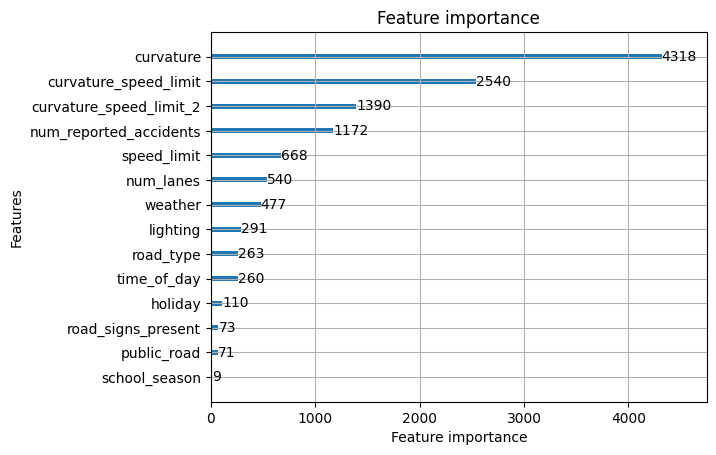

In [32]:
lgb.plot_importance(best_reg)

In [39]:
import joblib
import json

with open('models/lgb_optuna_best_params.json', 'w') as f:
    json.dump(study.best_params, f, indent=4)
joblib.dump(best_reg, 'best_lgb_optuna_model.pkl')

# with open('models/lgb_optuna_best_params.json') as param_file:
#    best_lgb_optuna_param = json.load(param_file)
# best_reg = joblib.load('best_lgb_model.pkl')

['best_lgb_optuna_model.pkl']

In [34]:
print(f'Test Score: {rmse(y_test, best_reg.predict(full_preprocessor.transform(X_test)))}')

Test Score: 0.05639359313516376


# Submit Prediction

In [35]:
full_test_csv = pd.read_csv('datasets/test.csv', index_col=0)
full_test_encoded = full_preprocessor.transform(full_test_csv)
full_test_encoded.head()

,road_type,weather,lighting,time_of_day,road_signs_present,public_road,holiday,school_season,num_lanes,curvature,speed_limit,num_reported_accidents,curvature_speed_limit,curvature_speed_limit_2
id,,,,,,,,,,,,,,
517754,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,2,0.34,45,1,15.30,688.50
517755,2.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,3,0.04,45,0,1.80,81.00
517756,2.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,2,0.59,35,1,20.65,722.75
517757,1.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,4,0.95,35,2,33.25,1163.75
517758,0.0,0.0,2.0,2.0,1.0,0.0,0.0,1.0,2,0.86,35,3,30.10,1053.50


## Best LGB Classifier

In [36]:
y_pred = best_reg.predict(full_test_encoded)

In [37]:
submission = pd.read_csv('datasets/sample_submission.csv', index_col=0)
print(submission.head())
submission[TARGET] = y_pred.round(3)
print('\n')
print(submission.head())
submission.to_csv('datasets/submission_LGBM_Optuna.csv')
print('Result saved successfully!')

        accident_risk
id                   
517754          0.352
517755          0.352
517756          0.352
517757          0.352
517758          0.352


        accident_risk
id                   
517754          0.296
517755          0.123
517756          0.179
517757          0.317
517758          0.409
Result saved successfully!


Public Score: 0.05565